## Работа на практике 9
**Вариант 14**
**Поток 22.5**
Выполнили:

Панченко Антон

Чистякова Екатерина



Даны две независимые выборки объёмов m = 51 и n = 53 из нормальных совокупностей.
Дисперсии неизвестны, но считаются равными. Для данных двух независимых выборок проверить гипотезу H0 : μ1 = μ2 против
H1 : μ1 ̸= μ2 на уровне значимости α = 0, 05 двусторонним критерием Стьюдента для двух
выборок с объединённой оценкой дисперсии.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

pd.options.display.max_rows = 15

#### Загрузка данных

In [9]:
x = pd.read_csv('variant_14_sample_X.csv')['x_i']
y = pd.read_csv('variant_14_sample_Y.csv')['y_j']

print(f"Размер выборки X (m): {len(x)}")
print(f"Размер выборки Y (n): {len(y)}")

Размер выборки X (m): 51
Размер выборки Y (n): 53


Выборочные характеристики
На основе исходных данных получены следующие характеристики:

**Выборочные средние:**

$\bar{x} = \frac{1}{m} \sum_{i=1}^{m} x_i = 46,6863$

$\bar{y} = \frac{1}{n} \sum_{j=1}^{n} y_j = 48,6415$

**Исправленные выборочные дисперсии:**

$s_x^2 = 24,9396$

$s_y^2 = 26,5422$

In [13]:
mean_x, var_x = np.mean(x), np.var(x, ddof=1)
mean_y, var_y = np.mean(y), np.var(y, ddof=1)

print(f"Выборка X: среднее = {mean_x:.3f}, дисперсия = {var_x:.3f}")
print(f"Выборка Y: среднее = {mean_y:.3f}, дисперсия = {var_y:.3f}")

Выборка X: среднее = 46.686, дисперсия = 24.940
Выборка Y: среднее = 48.642, дисперсия = 26.542


#### 3. Расчет t-статистики Стьюдента

Объединённая оценка дисперсии

$s_p^2 = \frac{(m - 1)s_x^2 + (n - 1)s_y^2}{m + n - 2} =  25,7566$

$s_p = 5,0751$

Наблюдаемое значение статистики

При справедливости $H_0$ статистика $T = \frac{\bar{x} - \bar{y}}{s_p \sqrt{\frac{1}{m} + \frac{1}{n}}}$
имеет распределение Стьюдента с $df = m + n - 2 = 102$ степенями свободы.

$T = -1,9641$

In [ ]:
alpha = 0.05
df = len(x) + len(y) - 2 # Число степеней свободы

pooled_var = ((len(x) - 1) * var_x + (len(y) - 1) * var_y) / df

se = np.sqrt(pooled_var * (1 / len(x) + 1 / len(y)))

t_stat = (mean_x - mean_y) / se
t_crit = stats.t.ppf(1 - alpha / 2, df)

p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"Объединенная дисперсия (S_p^2): {pooled_var:.3f}")
print(f"Стандартная ошибка (SE): {se:.3f}")
print(f"Эмпирическое значение t-критерия: {t_stat:.3f}")
print(f"Критическое значение t-критерия: {t_crit:.3f}")
print(f"p-value: {p_value:.4f}")

Объединенная дисперсия (S_p^2): 25.757
Стандартная ошибка (SE): 0.995
Эмпирическое значение t-критерия: -1.964
Критическое значение t-критерия: 1.983
p-value: 0.0522


In [12]:
# Сверка с готовой функцией scipy (equal_var=True указывает на равенство дисперсий)
t_stat_scipy, p_value_scipy = stats.ttest_ind(x, y, equal_var=True)

print(f"Проверка через SciPy:")
print(f"t-статистика: {t_stat_scipy:.3f}, p-value: {p_value_scipy:.4f}\n")

print("-" * 50)
print("ВЫВОД:")
if abs(t_stat) > t_crit:
    print(f"|{t_stat:.3f}| > {t_crit:.3f}")
    print("Эмпирическое значение попадает в критическую область.")
    print("Отклоняем нулевую гипотезу (H0). Различия между математическими ожиданиями статистически значимы.")
else:
    print(f"|{t_stat:.3f}| < {t_crit:.3f}")
    print("Эмпирическое значение НЕ попадает в критическую область (или p-value > alpha).")
    print("Принимаем нулевую гипотезу (H0). Различия между математическими ожиданиями случайны, оснований считать их разными нет.")
print("-" * 50)

Проверка через SciPy:
t-статистика: -1.964, p-value: 0.0522

--------------------------------------------------
ВЫВОД:
|-1.964| < 1.983
Эмпирическое значение НЕ попадает в критическую область (или p-value > alpha).
Принимаем нулевую гипотезу (H0). Различия между математическими ожиданиями случайны, оснований считать их разными нет.
--------------------------------------------------


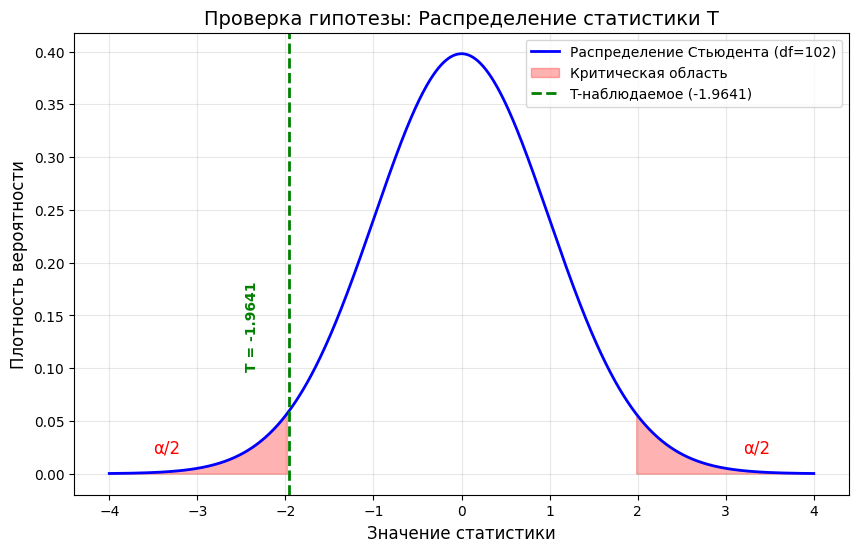

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Параметры из нашего расчета
df = 102
t_obs = -1.9641
t_crit = 1.9835
alpha = 0.05

# Создаем диапазон значений для оси X
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 6))

# Строим кривую распределения Стьюдента
plt.plot(x, y, 'b-', label=f'Распределение Стьюдента (df={df})', linewidth=2)

# Закрашиваем критические области (alpha/2 с каждой стороны)
x_crit_left = np.linspace(-4, -t_crit, 100)
plt.fill_between(x_crit_left, stats.t.pdf(x_crit_left, df), color='red', alpha=0.3, label='Критическая область')

x_crit_right = np.linspace(t_crit, 4, 100)
plt.fill_between(x_crit_right, stats.t.pdf(x_crit_right, df), color='red', alpha=0.3)

# Отмечаем наблюдаемое значение T
plt.axvline(t_obs, color='green', linestyle='--', linewidth=2, label=f'T-наблюдаемое ({t_obs:.4f})')

# Оформление
plt.title('Проверка гипотезы: Распределение статистики T', fontsize=14)
plt.xlabel('Значение статистики', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()

# Добавляем пояснение прямо на график
plt.text(t_obs - 0.5, 0.1, f'T = {t_stat:.5}', color='green', fontweight='bold', rotation=90)
plt.text(-3.5, 0.02, 'α/2', color='red', fontsize=12)
plt.text(3.2, 0.02, 'α/2', color='red', fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

Статистика и p-значение
Альтернатива двусторонняя, критическая область: 
$|T| > t$. Для $\alpha = 0,05$ и $df = 102$:
$t = t_{1-\alpha/2, 102} = t_{0,975, 102} = 1,9835$

Сравнение:

$|T| = 1,9641 < 1,9835 = t$

Подход на основе p-значения:

$p \approx 0,0522$

Так как $p > \alpha$ (0,0522 > 0,05), мы не имеем достаточных оснований для отклонения нулевой гипотезы.

**Вывод:** Гипотеза $H_0$ не отвергается. При $\alpha = 0,05$ данные не дают оснований утверждать, что математические ожидания двух генеральных совокупностей различаются. Разница средних объясняется случайной изменчивостью выборок.